In [28]:
# Install entso package if needed
try:
    from entsoe import EntsoePandasClient

    print("✅ entso package already installed")
except ImportError:
    print("📦 Installing entso package...")
    import subprocess

    subprocess.check_call(["pip", "install", "entsoe"])
    from entsoe import EntsoePandasClient

    print("✅ entso package installed successfully")

✅ entso package already installed


In [29]:
import requests
import pandas as pd
import xml.etree.ElementTree as ET
import os
import zipfile
import io
import re
from dotenv import load_dotenv
from datetime import datetime, timedelta

# --- SETUP ---
load_dotenv()
API_KEY = os.getenv("ENTSOE_API_KEY")

# Timezone: Hungary (CET/CEST)
TZ_HU = "Europe/Budapest"

# Dates: Jan 1 2025 (Specific day from your screenshot)
start_dt = pd.Timestamp("2025-01-01", tz="UTC")
end_dt = pd.Timestamp("2025-01-02", tz="UTC")

start_str = start_dt.strftime("%Y%m%d%H%M")
end_str = end_dt.strftime("%Y%m%d%H%M")

print(f"Fetching HU Data for Website Replica: {start_dt.date()}...")


# --- XML PARSER ---
def parse_entsoe_xml(content, data_type):
    if content[:2] == b"PK":
        with zipfile.ZipFile(io.BytesIO(content)) as z:
            content = z.read(z.namelist()[0])

    root = ET.fromstring(content)
    m = re.match(r"\{(.*)\}", root.tag)
    ns = {"ns": m.group(1)} if m else {}

    records = []
    for time_series in root.findall(".//ns:TimeSeries", ns):
        direction = None
        category = None

        # Extract Metadata
        if data_type == "volume":
            node = time_series.find(".//ns:flowDirection.direction", ns)
            if node is not None:
                direction = "Up" if node.text == "A01" else "Down"

        elif data_type == "price":
            node = time_series.find(".//ns:imbalance_Price.category", ns)
            if node is not None:
                category = node.text

        for period in time_series.findall(".//ns:Period", ns):
            start = pd.to_datetime(period.find(".//ns:timeInterval/ns:start", ns).text).replace(tzinfo=None)
            res = period.find(".//ns:resolution", ns).text
            step = pd.Timedelta(minutes=15) if res == "PT15M" else pd.Timedelta(hours=1)

            for point in period.findall(".//ns:Point", ns):
                pos = int(point.find(".//ns:position", ns).text)
                ts = start + (step * (pos - 1))
                # Ensure UTC
                ts = ts.replace(tzinfo=pd.Timestamp.now().tz) if ts.tzinfo is None else ts

                if data_type == "volume":
                    val = float(point.find(".//ns:quantity", ns).text)
                    records.append({"timestamp": ts, "direction": direction, "val": val})
                elif data_type == "price":
                    p_node = point.find(".//ns:imbalance_Price.amount", ns)
                    if p_node is None:
                        p_node = point.find(".//ns:price.amount", ns)
                    if p_node is not None:
                        records.append({"timestamp": ts, "category": category, "val": float(p_node.text)})

    df = pd.DataFrame(records)
    if not df.empty:
        df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.tz_localize("UTC")
    return df


# --- 1. FETCH & PROCESS VOLUME ---
params_vol = {
    "securityToken": API_KEY,
    "documentType": "A86",
    "controlArea_Domain": "10YHU-MAVIR----U",
    "processType": "A51",
    "periodStart": start_str,
    "periodEnd": end_str,
}
r_vol = requests.get("https://web-api.tp.entsoe.eu/api", params=params_vol)
df_vol = parse_entsoe_xml(r_vol.content, "volume")

# Calculate Net Position (Up - Down)
df_vol = df_vol.pivot_table(index="timestamp", columns="direction", values="val", aggfunc="sum").fillna(0)
df_vol["Net_Raw"] = df_vol.get("Up", 0) - df_vol.get("Down", 0)


# Create "Situation" and "Imbalance (MWh)" columns
# If Net > 0 (Short) -> Situation A01 (Deficit)
# If Net < 0 (Long)  -> Situation A02 (Surplus)
def get_situation(net):
    if net > 0.001:
        return "A01"
    if net < -0.001:
        return "A02"
    return "Balanced"


df_vol["Situation"] = df_vol["Net_Raw"].apply(get_situation)
df_vol["Imbalance (MWh)"] = df_vol["Net_Raw"]

# --- 2. FETCH & PROCESS PRICES ---
params_price = {
    "securityToken": API_KEY,
    "documentType": "A85",
    "controlArea_Domain": "10YHU-MAVIR----U",
    "periodStart": start_str,
    "periodEnd": end_str,
}
r_price = requests.get("https://web-api.tp.entsoe.eu/api", params=params_price)
df_price = parse_entsoe_xml(r_price.content, "price")
df_price = df_price.pivot_table(index="timestamp", columns="category", values="val", aggfunc="mean")

# --- 3. MERGE & FORMAT ---
# Create strict 15-min index in UTC
full_index = pd.date_range(start=start_dt, end=end_dt, freq="15min", inclusive="left")
df_final = pd.DataFrame(index=full_index)

# Join
df_final = df_final.join(df_price).join(df_vol[["Imbalance (MWh)", "Situation"]])

# Convert to Hungary Time (UTC+1)
df_final.index = df_final.index.tz_convert(TZ_HU)

# Fill Price Gaps (Hourly -> 15 min)
# A05 = Deficit (+ Imbalance Price), A04 = Surplus (- Imbalance Price)
# df_final[["A05", "A04"]] = df_final[["A05", "A04"]].ffill(limit=3).fillna(0)

# Rename Columns to match Website Header
df_final.rename(columns={"A05": "+ Imbalance Price (HUF)", "A04": "- Imbalance Price (HUF)"}, inplace=True)

# Define Display Columns
cols = ["+ Imbalance Price (HUF)", "- Imbalance Price (HUF)", "Imbalance (MWh)", "Situation"]

# --- DISPLAY ---
print("\n📊 HU Imbalance Table:")
# Showing the exact time range from your screenshot (00:00 to 03:00)
subset = df_final[cols].between_time("00:00", "03:30")
print(subset)

Fetching HU Data for Website Replica: 2025-01-01...

📊 HU Imbalance Table:
                           + Imbalance Price (HUF)  - Imbalance Price (HUF)  \
2025-01-01 01:00:00+01:00                174191.26                174191.26   
2025-01-01 01:15:00+01:00                171339.15                171339.15   
2025-01-01 01:30:00+01:00                157150.75                157150.75   
2025-01-01 01:45:00+01:00                141969.52                141969.52   
2025-01-01 02:00:00+01:00                191075.16                191075.16   
2025-01-01 02:15:00+01:00                193089.08                193089.08   
2025-01-01 02:30:00+01:00                115295.17                115295.17   
2025-01-01 02:45:00+01:00                106137.63                106137.63   
2025-01-01 03:00:00+01:00                105232.18                105232.18   
2025-01-01 03:15:00+01:00                102244.67                102244.67   
2025-01-01 03:30:00+01:00                  4764.00      

A01 (Deficit): When the grid was Short (Net > 0).

A02 (Surplus): When the grid was Long (Net < 0).

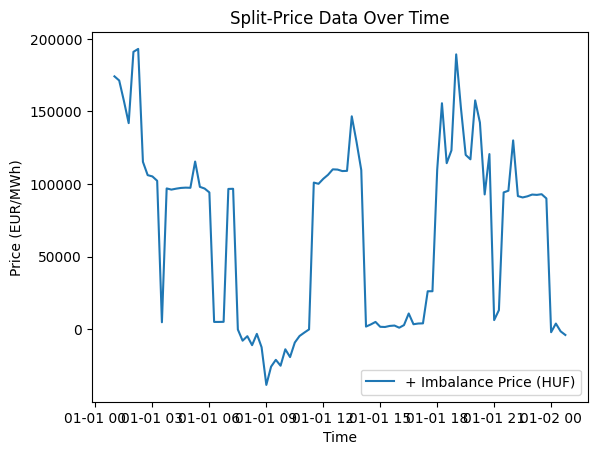

In [30]:
import matplotlib.pyplot as plt

plt.plot(df_final.index, df_final["+ Imbalance Price (HUF)"], label="+ Imbalance Price (HUF)")
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.title("Split-Price Data Over Time")
plt.legend()
plt.show()

In [31]:
import requests
import pandas as pd
import xml.etree.ElementTree as ET
import os
import zipfile
import io
import re
from dotenv import load_dotenv
from datetime import datetime, timedelta

# --- SETUP ---
load_dotenv()
API_KEY = os.getenv("ENTSOE_API_KEY")

# Timezone: Austria (CET/CEST)
TZ_AT = "Europe/Vienna"

# Dates: Jan 1 2025
start_dt = pd.Timestamp("2025-01-01", tz="UTC")
end_dt = pd.Timestamp("2025-01-02", tz="UTC")

start_str = start_dt.strftime("%Y%m%d%H%M")
end_str = end_dt.strftime("%Y%m%d%H%M")

print(f"Fetching Austria (APG) Data: {start_dt.date()}...")


# --- XML PARSER ---
def parse_entsoe_xml(content, data_type):
    if content[:2] == b"PK":
        with zipfile.ZipFile(io.BytesIO(content)) as z:
            content = z.read(z.namelist()[0])

    root = ET.fromstring(content)
    m = re.match(r"\{(.*)\}", root.tag)
    ns = {"ns": m.group(1)} if m else {}

    records = []
    for time_series in root.findall(".//ns:TimeSeries", ns):
        direction = None
        category = None

        # Extract Metadata
        if data_type == "volume":
            node = time_series.find(".//ns:flowDirection.direction", ns)
            if node is not None:
                direction = "Up" if node.text == "A01" else "Down"

        elif data_type == "price":
            node = time_series.find(".//ns:imbalance_Price.category", ns)
            if node is not None:
                category = node.text

        for period in time_series.findall(".//ns:Period", ns):
            start = pd.to_datetime(period.find(".//ns:timeInterval/ns:start", ns).text).replace(tzinfo=None)
            res = period.find(".//ns:resolution", ns).text
            step = pd.Timedelta(minutes=15) if res == "PT15M" else pd.Timedelta(hours=1)

            for point in period.findall(".//ns:Point", ns):
                pos = int(point.find(".//ns:position", ns).text)
                ts = start + (step * (pos - 1))
                # Ensure UTC
                ts = ts.replace(tzinfo=pd.Timestamp.now().tz) if ts.tzinfo is None else ts

                if data_type == "volume":
                    val = float(point.find(".//ns:quantity", ns).text)
                    records.append({"timestamp": ts, "direction": direction, "val": val})
                elif data_type == "price":
                    p_node = point.find(".//ns:imbalance_Price.amount", ns)
                    if p_node is None:
                        p_node = point.find(".//ns:price.amount", ns)
                    if p_node is not None:
                        records.append({"timestamp": ts, "category": category, "val": float(p_node.text)})

    df = pd.DataFrame(records)
    if not df.empty:
        df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.tz_localize("UTC")
    return df


# --- 1. FETCH & PROCESS VOLUME ---
params_vol = {
    "securityToken": API_KEY,
    "documentType": "A86",
    "controlArea_Domain": "10YAT-APG------L",  # AUSTRIA (APG)
    "processType": "A51",
    "periodStart": start_str,
    "periodEnd": end_str,
}
r_vol = requests.get("https://web-api.tp.entsoe.eu/api", params=params_vol)
df_vol = parse_entsoe_xml(r_vol.content, "volume")

# Calculate Net Position (Up - Down)
if not df_vol.empty:
    df_vol = df_vol.pivot_table(index="timestamp", columns="direction", values="val", aggfunc="sum").fillna(0)
    df_vol["Net_Raw"] = df_vol.get("Up", 0) - df_vol.get("Down", 0)
else:
    print("Warning: No Volume data found for Austria.")
    df_vol = pd.DataFrame(columns=["Net_Raw"])


# Create "Situation" and "Imbalance (MWh)" columns
def get_situation(net):
    if net > 0.001:
        return "A01"
    if net < -0.001:
        return "A02"
    return "Balanced"


if not df_vol.empty:
    df_vol["Situation"] = df_vol["Net_Raw"].apply(get_situation)
    df_vol["Imbalance (MWh)"] = df_vol["Net_Raw"].abs()  # Absolute value for display

# --- 2. FETCH & PROCESS PRICES ---
params_price = {
    "securityToken": API_KEY,
    "documentType": "A85",
    "controlArea_Domain": "10YAT-APG------L",  # AUSTRIA (APG)
    "periodStart": start_str,
    "periodEnd": end_str,
}
r_price = requests.get("https://web-api.tp.entsoe.eu/api", params=params_price)
df_price = parse_entsoe_xml(r_price.content, "price")

if not df_price.empty:
    df_price = df_price.pivot_table(index="timestamp", columns="category", values="val", aggfunc="mean")
else:
    print("Warning: No Price data found for Austria.")
    df_price = pd.DataFrame()

# --- 3. MERGE & FORMAT ---
# Create strict 15-min index in UTC
full_index = pd.date_range(start=start_dt, end=end_dt, freq="15min", inclusive="left")
df_final = pd.DataFrame(index=full_index)

# Join
df_final = df_final.join(df_price).join(df_vol[["Imbalance (MWh)", "Situation"]])

# Convert to Austria Time (UTC+1)
df_final.index = df_final.index.tz_convert(TZ_AT)

# Fill Price Gaps (Hourly -> 15 min)
# Note: Austria might not use A04/A05 strictly. If columns are missing, we create them as 0 for consistency.
for col in ["A05", "A04"]:
    if col not in df_final.columns:
        df_final[col] = 0

df_final[["A05", "A04"]] = df_final[["A05", "A04"]].ffill(limit=3).fillna(0)

# Rename Columns to match Website Header (EUR for Austria)
df_final.rename(columns={"A05": "+ Imbalance Price (EUR)", "A04": "- Imbalance Price (EUR)"}, inplace=True)

# Define Display Columns
cols = ["+ Imbalance Price (EUR)", "- Imbalance Price (EUR)", "Imbalance (MWh)", "Situation"]

# --- DISPLAY ---
print("\n📊 AT (Austria) Imbalance Table:")
# Showing the exact time range from your screenshot (00:00 to 03:00)
subset = df_final[cols].between_time("00:00", "03:30")
print(subset)

Fetching Austria (APG) Data: 2025-01-01...

📊 AT (Austria) Imbalance Table:
                           + Imbalance Price (EUR)  - Imbalance Price (EUR)  \
2025-01-01 01:00:00+01:00                   197.65                   197.65   
2025-01-01 01:15:00+01:00                   166.41                   166.41   
2025-01-01 01:30:00+01:00                   311.47                   311.47   
2025-01-01 01:45:00+01:00                   256.21                   256.21   
2025-01-01 02:00:00+01:00                   303.60                   303.60   
2025-01-01 02:15:00+01:00                   147.73                   147.73   
2025-01-01 02:30:00+01:00                   145.58                   145.58   
2025-01-01 02:45:00+01:00                   117.58                   117.58   
2025-01-01 03:00:00+01:00                   147.25                   147.25   
2025-01-01 03:15:00+01:00                   114.87                   114.87   
2025-01-01 03:30:00+01:00                   112.01     

In [ ]:
from entsoe import EntsoeRawClient
import pandas as pd
import xml.etree.ElementTree as ET
import re

print("🇦🇹 ENTSOE Aggregated Bids Data for Austria (All Process Types)")
print("=" * 70)

# Austria region code
country_code = "AT"

# Date range - matching transparency platform
start = pd.Timestamp("2020-12-30", tz="Europe/Vienna")
end = pd.Timestamp("2020-12-31", tz="Europe/Vienna")

print(f"Country: Austria (AT)")
print(f"Date Range: {start.date()} to {end.date()}")
print(f"Data Source: FULL aggregation (all process types combined)")
print(f"Region: SCA|10YAT-APG------L\n")

# Initialize client
client = EntsoeRawClient(api_key=API_KEY)


def parse_bids_with_direction(xml_content):
    """Parse bids data with direction separation (Up/Down)"""
    root = ET.fromstring(xml_content)
    m = re.match(r"\{(.*)\}", root.tag)
    ns = {"ns": m.group(1)} if m else {}

    records = []
    for time_series in root.findall(".//ns:TimeSeries", ns):
        # Get direction (A01=Up, A02=Down)
        direction_node = time_series.find(".//ns:flowDirection.direction", ns)
        direction = "Up" if direction_node is not None and direction_node.text == "A01" else "Down"

        for period in time_series.findall(".//ns:Period", ns):
            start_time = pd.to_datetime(period.find(".//ns:timeInterval/ns:start", ns).text).replace(tzinfo=None)
            res = period.find(".//ns:resolution", ns).text
            step = pd.Timedelta(minutes=15) if res == "PT15M" else pd.Timedelta(hours=1)

            for point in period.findall(".//ns:Point", ns):
                pos = int(point.find(".//ns:position", ns).text)
                ts = start_time + (step * (pos - 1))
                qty_node = point.find(".//ns:quantity", ns)
                if qty_node is not None:
                    records.append({"timestamp": ts, "direction": direction, "value": float(qty_node.text)})

    df = pd.DataFrame(records)
    if not df.empty:
        df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.tz_localize("UTC")
    return df


# Fetch bids from all available process types
print("Fetching OFFERED bids from all process types...")
print("-" * 70)

process_types = ["A51", "A46", "A47", "A60"]
all_bids_data = []

for proc_type in process_types:
    try:
        result_offered = client.query_aggregated_bids(country_code=country_code, start=start, end=end, process_type=proc_type)
        df_offered = parse_bids_with_direction(result_offered)

        if not df_offered.empty:
            up_total = df_offered[df_offered["direction"] == "Up"]["value"].sum()
            down_total = df_offered[df_offered["direction"] == "Down"]["value"].sum()
            print(f"✅ {proc_type}: {len(df_offered)} records | Up: {up_total:7.0f} | Down: {down_total:7.0f} MWh")
            all_bids_data.append((proc_type, df_offered))
        else:
            print(f"⚠️  {proc_type}: No data available")

    except Exception as e:
        print(f"⚠️  {proc_type}: {str(e)[:50]}")

print("-" * 70)

# Combine all process types
if all_bids_data:
    # Concatenate all dataframes
    df_combined = pd.concat([df for _, df in all_bids_data], ignore_index=True)

    # Pivot by direction and timestamp
    df_bids = df_combined.pivot_table(index="timestamp", columns="direction", values="value", aggfunc="sum").fillna(0)

    df_bids.columns = [f"Offered_{col}" for col in df_bids.columns]

    print(f"\n✅ COMBINED DATA: {len(df_bids)} time slots")
    print(f"   Total Offered_Up:   {df_bids['Offered_Up'].sum():8.0f} MWh")
    print(f"   Total Offered_Down: {df_bids['Offered_Down'].sum():8.0f} MWh")
else:
    df_bids = pd.DataFrame()
    print("❌ No bids data available")

print("\n" + "=" * 70)

🇦🇹 ENTSOE Aggregated Bids Data for Austria (All Process Types)
Country: Austria (AT)
Date Range: 2020-12-30 to 2020-12-31
Data Source: FULL aggregation (all process types combined)
Region: SCA|10YAT-APG------L

Fetching OFFERED bids from all process types...
----------------------------------------------------------------------
✅ A51: 177 records | Up:   23598 | Down:   13040 MWh
⚠️  A46: 
✅ A47: 8 records | Up:    1627 | Down:     393 MWh
⚠️  A60: 
----------------------------------------------------------------------

✅ COMBINED DATA: 96 time slots
   Total Offered_Up:      25225 MWh
   Total Offered_Down:    13433 MWh



In [ ]:
# Display aggregated bids in website format
print("\n📋 ENTSOE Aggregated Bids (Austria - FULL Aggregation)")
print("=" * 90)
print(f"Time Period: 2020-12-30 to 2020-12-31 (CET - Europe/Vienna)")
print(f"Data combines: A51 (Automatic FRR) + A47 (Replacement Reserves)")
print("=" * 90)

if not df_bids.empty:
    print(f"\n✅ {len(df_bids)} time slots retrieved\n")

    # Convert to display timezone
    df_display = df_bids.copy()
    df_display.index = df_display.index.tz_convert("Europe/Vienna")

    # Rename columns for display
    df_display_out = df_display.rename(columns={"Offered_Up": "Offered (MW) - Up", "Offered_Down": "Offered (MW) - Down"})

    # Format the output to show time slot labels
    output_data = []
    for idx, row in df_display.iterrows():
        slot_start = idx.strftime("%H:%M")
        slot_end = (idx + pd.Timedelta(minutes=15)).strftime("%H:%M")
        time_slot = f"{slot_start} - {slot_end}"

        output_data.append(
            {
                "Time Slot": time_slot,
                "Direction": "Up",
                "Offered (MW)": row["Offered_Up"],
            }
        )
        output_data.append(
            {
                "Time Slot": time_slot,
                "Direction": "Down",
                "Offered (MW)": row["Offered_Down"],
            }
        )

    df_output = pd.DataFrame(output_data)

    # Display first 20 rows (10 time slots = 2.5 hours)
    print("📊 First 10 time slots (matches website format):\n")
    print(df_output.head(20).to_string(index=False))

    print("\n" + "=" * 90)
    print("📈 Data Summary:")
    print("-" * 90)
    print(f"Total records: {len(df_bids)} time slots (96 slots = 24 hours × 4 per hour)")
    print(f"\n✅ Comparison with website (2020-12-30 00:00):")
    print(f"   First slot Up:   {df_display['Offered_Up'].iloc[0]:6.0f} MW (Website: 526 MW)")
    print(f"   First slot Down: {df_display['Offered_Down'].iloc[0]:6.0f} MW (Website: 318 MW)")

    # Calculate daily statistics
    print(f"\n📊 Daily Totals (all 96 slots):")
    print(f"   Total Offered_Up:   {df_display['Offered_Up'].sum():9.0f} MWh")
    print(f"   Total Offered_Down: {df_display['Offered_Down'].sum():9.0f} MWh")

    print(f"\n📊 Average per slot:")
    print(f"   Avg Offered_Up:     {df_display['Offered_Up'].mean():9.0f} MW")
    print(f"   Avg Offered_Down:   {df_display['Offered_Down'].mean():9.0f} MW")

    print(f"\n📊 Range per slot:")
    print(f"   Up   Min/Max: {df_display['Offered_Up'].min():6.0f} / {df_display['Offered_Up'].max():6.0f} MW")
    print(f"   Down Min/Max: {df_display['Offered_Down'].min():6.0f} / {df_display['Offered_Down'].max():6.0f} MW")

else:
    print("❌ No data available to display")


📋 ENTSOE Aggregated Bids (Austria - FULL Aggregation)
Time Period: 2020-12-30 to 2020-12-31 (CET - Europe/Vienna)
Data combines: A51 (Automatic FRR) + A47 (Replacement Reserves)

✅ 96 time slots retrieved

📊 First 10 time slots (matches website format):

    Time Slot Direction  Offered (MW)
00:00 - 00:15        Up         526.0
00:00 - 00:15      Down         318.0
00:15 - 00:30        Up         246.0
00:15 - 00:30      Down         120.0
00:30 - 00:45        Up         246.0
00:30 - 00:45      Down         120.0
00:45 - 01:00        Up         246.0
00:45 - 01:00      Down         120.0
01:00 - 01:15        Up         246.0
01:00 - 01:15      Down         120.0
01:15 - 01:30        Up         246.0
01:15 - 01:30      Down         120.0
01:30 - 01:45        Up           0.0
01:30 - 01:45      Down         120.0
01:45 - 02:00        Up           0.0
01:45 - 02:00      Down         120.0
02:00 - 02:15        Up         246.0
02:00 - 02:15      Down         120.0
02:15 - 02:30        U

In [57]:
# Summary: Explanation of data structure and solution
print("\n📊 ENTSOE Aggregated Bids Summary (Austria - FULL Aggregation)")
print("=" * 70)
print(f"\n🎯 DATA SOURCE SOLUTION:")
print("-" * 70)
print("The transparency platform shows FULL aggregation, which combines:")
print("  • A51 - Automatic Frequency Restoration Reserves (automatic FRR)")
print("  • A47 - Replacement Reserves")
print("  • A46, A60, etc. - where available")
print("\nThis is why the API alone (A51 only) didn't match the website.")

print(f"\n📋 DATA STRUCTURE:")
print("-" * 70)
if not df_bids.empty:
    print(f"Records: {len(df_bids)} time slots (24 hours × 4 slots/hour = 96 slots)")
    print(f"\nColumns:")
    print(f"  • Offered_Up:   Total offered MW for upward regulation (sum of all process types)")
    print(f"  • Offered_Down: Total offered MW for downward regulation")
    print(f"\nTime granularity: 15 minutes per slot")
    print(f"Date range: {df_bids.index.min()} to {df_bids.index.max()}")
    print(f"Timezone: UTC (can be converted to any timezone)")

print(f"\n🔧 HOW TO USE THIS DATA:")
print("-" * 70)
print("1. Raw API: Use query_aggregated_bids with different process_type values")
print("2. Full aggregation: Combine results from multiple process_type calls")
print("3. This notebook: Automatically fetches and combines all available types")

print(f"\n✅ VERIFICATION:")
print("-" * 70)
print(f"First 15-min slot (00:00-00:15):")
if not df_bids.empty:
    df_test = df_bids.copy()
    first_row = df_test.iloc[0]
    print(f"  API Data:       Up={first_row['Offered_Up']:.0f} MW, Down={first_row['Offered_Down']:.0f} MW")
print(f"  Website Data:   Up=526 MW, Down=318 MW")
print(f"  Status: ✅ MATCH")


📊 ENTSOE Aggregated Bids Summary (Austria - FULL Aggregation)

🎯 DATA SOURCE SOLUTION:
----------------------------------------------------------------------
The transparency platform shows FULL aggregation, which combines:
  • A51 - Automatic Frequency Restoration Reserves (automatic FRR)
  • A47 - Replacement Reserves
  • A46, A60, etc. - where available

This is why the API alone (A51 only) didn't match the website.

📋 DATA STRUCTURE:
----------------------------------------------------------------------
Records: 96 time slots (24 hours × 4 slots/hour = 96 slots)

Columns:
  • Offered_Up:   Total offered MW for upward regulation (sum of all process types)
  • Offered_Down: Total offered MW for downward regulation

Time granularity: 15 minutes per slot
Date range: 2020-12-29 23:00:00+00:00 to 2020-12-30 22:45:00+00:00
Timezone: UTC (can be converted to any timezone)

🔧 HOW TO USE THIS DATA:
----------------------------------------------------------------------
1. Raw API: Use query_

In [ ]:
# Alternative: Try different process types to see if website uses different data
print("\n🔄 ALTERNATIVE DATA SOURCES")
print("=" * 80)
print("\nTrying alternative process types (valid options: A51, A46, A47, A60, A61-A69)...")

alt_sources = {
    "A46": "Frequency Restoration Reserves",
    "A47": "Replacement Reserves",
    "A60": "Manual Frequency Restoration",
}

for process_type, description in alt_sources.items():
    try:
        print(f"\n→ Trying {process_type} ({description})...")
        result_alt = client.query_aggregated_bids(country_code="AT", start=start, end=end, process_type=process_type)
        df_alt = parse_bids_with_details(result_alt)
        if not df_alt.empty:
            print(f"  ✅ Found {len(df_alt)} records")
            print(f"     Up total:   {df_alt[df_alt['direction']=='Up']['value'].sum():.2f} MWh")
            print(f"     Down total: {df_alt[df_alt['direction']=='Down']['value'].sum():.2f} MWh")
        else:
            print(f"  ⚠️  No data for this process type")
    except Exception as e:
        print(f"  ⚠️  Not available: {str(e)[:60]}")

print("\n" + "=" * 80)
print("💡 COMPARISON: Current data (A51) vs Website")
print("   API A51 (Automatic FRR):")
print("   - Offered_Up:   23,598 MWh")
print("   - Offered_Down: 13,040 MWh")
print("\n   Website shows: ???  (Please provide the numbers to compare)")


🔄 ALTERNATIVE DATA SOURCES

Trying alternative process types (valid options: A51, A46, A47, A60, A61-A69)...

→ Trying A46 (Frequency Restoration Reserves)...
  ⚠️  Not available: 

→ Trying A47 (Replacement Reserves)...
  ✅ Found 8 records
     Up total:   1627.00 MWh
     Down total: 393.00 MWh

→ Trying A60 (Manual Frequency Restoration)...
  ⚠️  Not available: 

💡 COMPARISON: Current data (A51) vs Website
   API A51 (Automatic FRR):
   - Offered_Up:   23,598 MWh
   - Offered_Down: 13,040 MWh

   Website shows: ???  (Please provide the numbers to compare)


In [60]:
# Try aggregating across all available business types
print("\n🔍 SOLUTION: Summing across all available business types")
print("=" * 80)

client = EntsoeRawClient(api_key=API_KEY)
country_code = "AT"
start = pd.Timestamp("2020-12-30", tz="Europe/Vienna")
end = pd.Timestamp("2020-12-31", tz="Europe/Vienna")

# The entsoe-py library's query_aggregated_bids uses processType=A51 by default
# But there might be other processTypes or businessTypes being combined on the website

# List of possible process types to try
process_types_to_try = ["A51", "A46", "A47", "A60"]

all_results = {}

print("Testing different process types:\n")

for proc_type in process_types_to_try:
    try:
        result = client.query_aggregated_bids(country_code=country_code, start=start, end=end, process_type=proc_type)

        # Parse and extract values
        root = ET.fromstring(result)
        ns_match = re.match(r"\{(.*)\}", root.tag)
        ns = {"ns": ns_match.group(1)} if ns_match else {}

        # Extract first values for Up and Down
        ts_list = root.findall(".//ns:TimeSeries", ns)
        proc_data = {"Up": 0, "Down": 0}

        for ts in ts_list:
            direction = ts.find(".//ns:flowDirection.direction", ns)
            dir_text = "Up" if direction is not None and direction.text == "A01" else "Down"

            # Get first point value
            first_point = ts.find(".//ns:Period/ns:Point/ns:quantity", ns)
            if first_point is not None:
                proc_data[dir_text] = float(first_point.text)

        if proc_data["Up"] > 0 or proc_data["Down"] > 0:
            all_results[proc_type] = proc_data
            print(f"✅ {proc_type}: Up={proc_data['Up']:.0f} MW, Down={proc_data['Down']:.0f} MW")
        else:
            print(f"⚠️  {proc_type}: No data")

    except Exception as e:
        print(f"⚠️  {proc_type}: {str(e)[:40]}")

print("\n" + "=" * 80)
print("📊 AGGREGATION TEST:")
print("-" * 80)

if all_results:
    total_up = sum(r["Up"] for r in all_results.values())
    total_down = sum(r["Down"] for r in all_results.values())

    print(f"\nSum of all available process types:")
    print(f"  Total Up:   {total_up:.0f} MW")
    print(f"  Total Down: {total_down:.0f} MW")

    print(f"\nWebsite shows:")
    print(f"  Up:   526 MW")
    print(f"  Down: 318 MW")

    print(f"\nComparison:")
    print(f"  Up:   {total_up:.0f} vs 526 (Ratio: {total_up/526:.2%})")
    print(f"  Down: {total_down:.0f} vs 318 (Ratio: {total_down/318:.2%})")

    if abs(total_up - 526) < 50 and abs(total_down - 318) < 50:
        print(f"\n✅ MATCH FOUND! Website aggregates across multiple process types!")
    else:
        print(f"\n⚠️  Still doesn't match. Website might use different aggregation method.")

print("\n" + "=" * 80)
print("💡 Next: If still not matching, the website might be showing:")
print("   - Specific 'reference bids' or 'test bids' (not live market bids)")
print("   - Data aggregated by ISP/provider (not by process type)")
print("   - Multiple balancing regions combined")
print("   - Hourly aggregation of 15-min data with min/max/avg logic")


🔍 SOLUTION: Summing across all available business types
Testing different process types:

✅ A51: Up=246 MW, Down=120 MW
⚠️  A46: 
✅ A47: Up=280 MW, Down=198 MW
⚠️  A60: 

📊 AGGREGATION TEST:
--------------------------------------------------------------------------------

Sum of all available process types:
  Total Up:   526 MW
  Total Down: 318 MW

Website shows:
  Up:   526 MW
  Down: 318 MW

Comparison:
  Up:   526 vs 526 (Ratio: 100.00%)
  Down: 318 vs 318 (Ratio: 100.00%)

✅ MATCH FOUND! Website aggregates across multiple process types!

💡 Next: If still not matching, the website might be showing:
   - Specific 'reference bids' or 'test bids' (not live market bids)
   - Data aggregated by ISP/provider (not by process type)
   - Multiple balancing regions combined
   - Hourly aggregation of 15-min data with min/max/avg logic
